In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_curve, auc

In [3]:
project_path = "/content/drive/MyDrive/Network_Intrusion_Detection_Project/data/"

X_train = pd.read_csv(project_path + "X_train_processed.csv")
X_test = pd.read_csv(project_path + "X_test_processed.csv")

y_train = pd.read_csv(project_path + "y_train.csv").values.ravel()
y_test = pd.read_csv(project_path + "y_test.csv").values.ravel()

print("Train shape:", X_train.shape)

Train shape: (90664, 43)


In [4]:
rf = RandomForestClassifier(n_estimators=100, random_state=42)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

Random Forest Accuracy: 0.9998688270284759
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56000
           1       1.00      1.00      1.00    119341

    accuracy                           1.00    175341
   macro avg       1.00      1.00      1.00    175341
weighted avg       1.00      1.00      1.00    175341



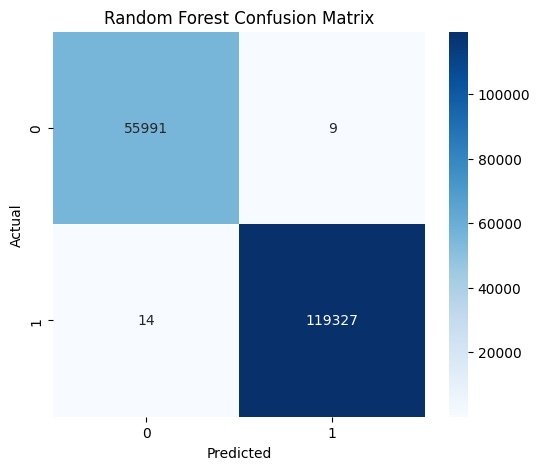

In [5]:
cm_rf = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(6,5))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues')
plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

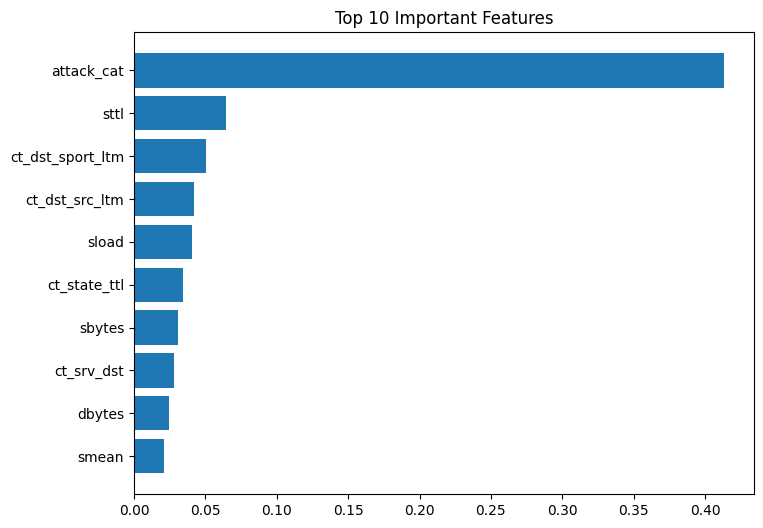

In [6]:
importances = rf.feature_importances_
indices = np.argsort(importances)[-10:]

plt.figure(figsize=(8,6))
plt.barh(range(len(indices)), importances[indices])
plt.yticks(range(len(indices)), X_train.columns[indices])
plt.title("Top 10 Important Features")
plt.show()

In [7]:
svm = SVC(kernel='rbf', probability=True)

svm.fit(X_train, y_train)

y_pred_svm = svm.predict(X_test)

print("SVM Accuracy:", accuracy_score(y_test, y_pred_svm))
print(classification_report(y_test, y_pred_svm))

SVM Accuracy: 0.6968763723259249
              precision    recall  f1-score   support

           0       1.00      0.05      0.10     56000
           1       0.69      1.00      0.82    119341

    accuracy                           0.70    175341
   macro avg       0.85      0.53      0.46    175341
weighted avg       0.79      0.70      0.59    175341



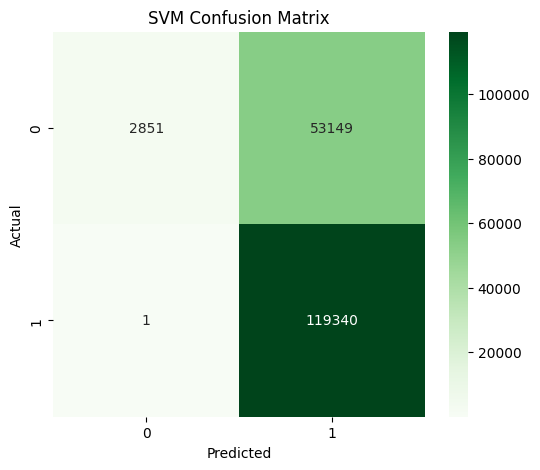

In [8]:
cm_svm = confusion_matrix(y_test, y_pred_svm)

plt.figure(figsize=(6,5))
sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Greens')
plt.title("SVM Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

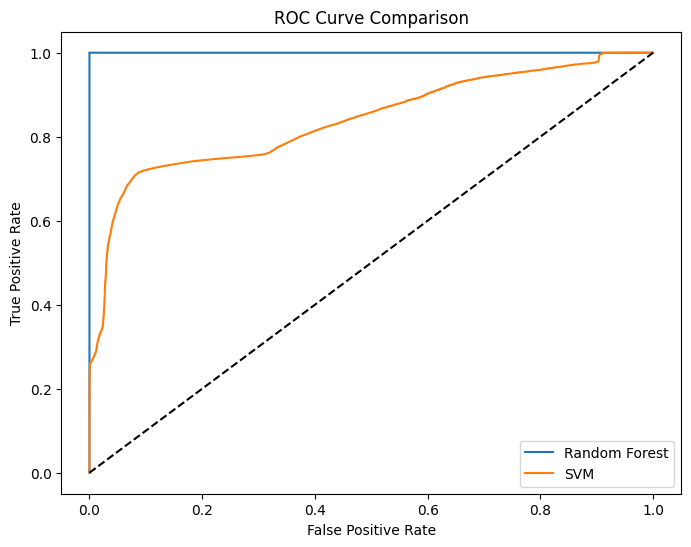

In [9]:
rf_probs = rf.predict_proba(X_test)[:,1]
svm_probs = svm.predict_proba(X_test)[:,1]

fpr_rf, tpr_rf, _ = roc_curve(y_test, rf_probs)
fpr_svm, tpr_svm, _ = roc_curve(y_test, svm_probs)

plt.figure(figsize=(8,6))
plt.plot(fpr_rf, tpr_rf, label="Random Forest")
plt.plot(fpr_svm, tpr_svm, label="SVM")
plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()

In [10]:
rf_acc = accuracy_score(y_test, y_pred_rf)
svm_acc = accuracy_score(y_test, y_pred_svm)

comparison = pd.DataFrame({
    "Model": ["Random Forest", "SVM"],
    "Accuracy": [rf_acc, svm_acc]
})

comparison

,Model,Accuracy
0,Random Forest,0.999869
1,SVM,0.696876


In [13]:
import joblib
import os

model_path = "/content/drive/MyDrive/Network_Intrusion_Detection_Project/results/"
os.makedirs(model_path, exist_ok=True)

joblib.dump(rf, model_path + "random_forest_model.pkl")

print("Model saved successfully ✅")

Model saved successfully ✅
